In [1]:
import os

data_path = "/kaggle/input/datasets/vishwasmishra1234/trash-net"

for folder in os.listdir(data_path):
    print(folder)
for folder in os.listdir(data_path):
    folder_path = os.path.join(data_path, folder)
    if os.path.isdir(folder_path):
        print(folder, ":", len(os.listdir(folder_path)))

train_imgEFFICIENTNET
val_imgEFFICIENTNET
train_imgEFFICIENTNET : 4
val_imgEFFICIENTNET : 4


In [2]:
import os
import matplotlib.pyplot as plt
import cv2
import random
from sklearn.metrics import confusion_matrix   
def show_images(split, class_name):
    folder = os.path.join(data_path, split, class_name)
    
    print("Using path:", folder)  # debug (important)
    
    if not os.path.exists(folder):
        print("❌ Wrong path. Check split/class name.")
        return
    
    images = os.listdir(folder)
    
    plt.figure(figsize=(10,5))
    
    for i in range(5):
        img_path = os.path.join(folder, random.choice(images))
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        plt.subplot(1,5,i+1)
        plt.imshow(img)
        plt.axis("off")
    
    plt.suptitle(f"{split} - {class_name}")
    plt.show()

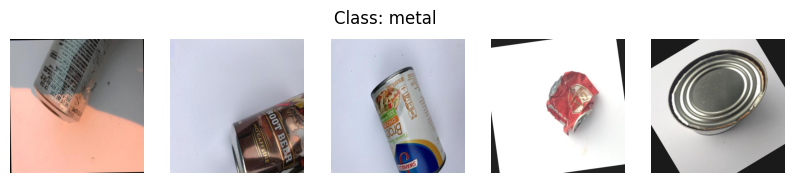

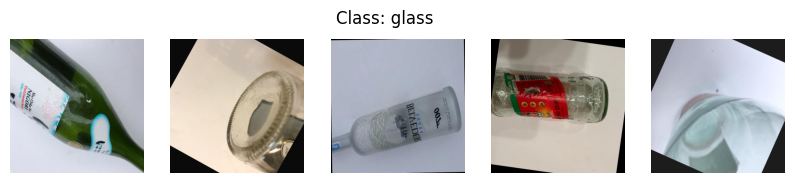

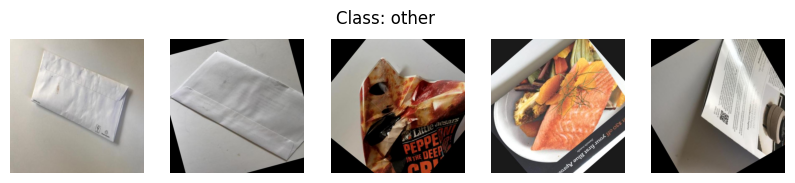

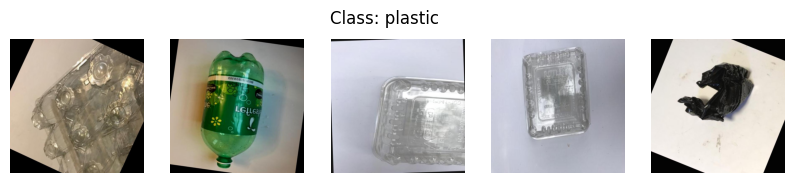

In [3]:
train_path = os.path.join(data_path, "train_imgEFFICIENTNET")
classes = os.listdir(train_path)

for cls in classes:
    folder = os.path.join(train_path, cls)
    images = os.listdir(folder)
    
    plt.figure(figsize=(10,2))
    
    for i in range(5):
        img_path = os.path.join(folder, random.choice(images))
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        plt.subplot(1,5,i+1)
        plt.imshow(img)
        plt.axis("off")
    
    plt.suptitle(f"Class: {cls}")
    plt.show()

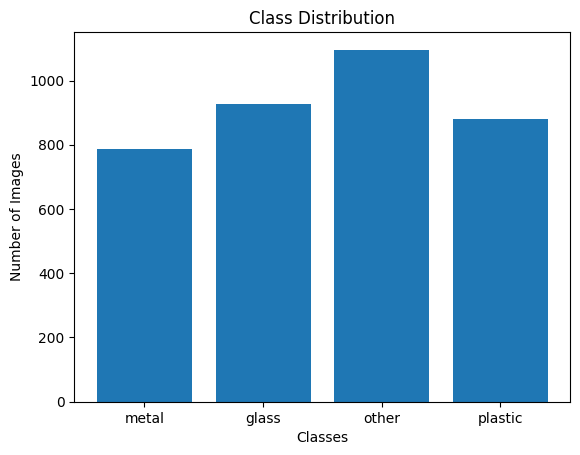

In [4]:
class_counts = {}

for cls in classes:
    class_counts[cls] = len(os.listdir(os.path.join(train_path, cls)))

plt.bar(class_counts.keys(), class_counts.values())
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.show()

In [5]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

train_path = "/kaggle/input/datasets/vishwasmishra1234/trash-net/train_imgEFFICIENTNET"
val_path = "/kaggle/input/datasets/vishwasmishra1234/trash-net/val_imgEFFICIENTNET"

In [6]:
#data augmentation for increasing dataset
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.RandomRotation(10),
    
    transforms.ToTensor(),  # ✅ convert to tensor FIRST
    
    transforms.RandomErasing(p=0.3),
])

In [7]:
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

In [8]:
train_dataset = datasets.ImageFolder(train_path, transform=train_transforms)
val_dataset = datasets.ImageFolder(val_path, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

In [9]:
print(train_dataset.classes)

['glass', 'metal', 'other', 'plastic']


In [10]:
import timm
import torch.nn as nn

model = timm.create_model('efficientnet_b0', pretrained=True)

# Modify final layer
model.classifier = nn.Linear(model.classifier.in_features, 4)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

In [11]:
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

In [12]:
num_epochs = 10
train_losses = []
val_losses = []
train_accs = []
val_accs = []

best_val_acc = 0
patience = 2
counter = 0

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    
    # ---- TRAIN ----
    model.train()
    train_loss = 0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        # 🔥 FIX 1: proper loss accumulation
        train_loss += loss.item() * images.size(0)
        
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    # 🔥 FIX 2: average loss
    train_loss = train_loss / total
    train_acc = 100 * correct / total
    
    # ---- VALIDATION ----
    model.eval()
    val_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # 🔥 FIX 3: proper loss accumulation
            val_loss += loss.item() * images.size(0)
            
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    # 🔥 FIX 4: average loss
    val_loss = val_loss / total
    val_acc = 100 * correct / total
    
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    
    # 🔥 FIX 5: store metrics for plotting
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    # ---- EARLY STOPPING ----
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")
        counter = 0
    else:
        counter += 1
    
    if counter >= patience:
        print("Early stopping triggered")
        break


Epoch 1/10
Train Loss: 0.6906 | Train Acc: 74.86%
Val Loss: 0.2725 | Val Acc: 90.82%

Epoch 2/10
Train Loss: 0.2757 | Train Acc: 90.30%
Val Loss: 0.1423 | Val Acc: 95.79%

Epoch 3/10
Train Loss: 0.1654 | Train Acc: 94.66%
Val Loss: 0.0809 | Val Acc: 97.52%

Epoch 4/10
Train Loss: 0.1215 | Train Acc: 95.86%
Val Loss: 0.0845 | Val Acc: 97.19%

Epoch 5/10
Train Loss: 0.0919 | Train Acc: 97.18%
Val Loss: 0.0641 | Val Acc: 97.73%

Epoch 6/10
Train Loss: 0.0790 | Train Acc: 97.67%
Val Loss: 0.0367 | Val Acc: 99.03%

Epoch 7/10
Train Loss: 0.0710 | Train Acc: 98.13%
Val Loss: 0.0429 | Val Acc: 98.27%

Epoch 8/10
Train Loss: 0.0662 | Train Acc: 97.70%
Val Loss: 0.0446 | Val Acc: 98.27%
Early stopping triggered


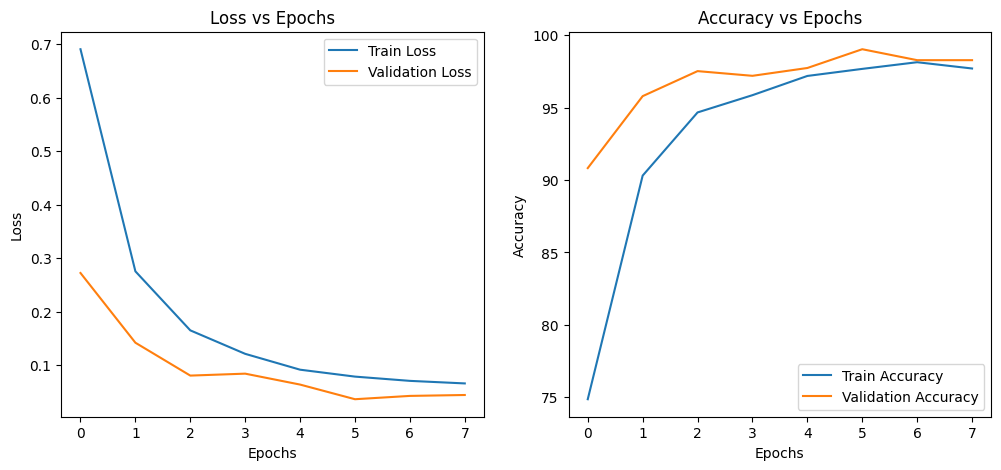

In [13]:
plt.figure(figsize=(12,5))

# Loss Plot
plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")

# Accuracy Plot
plt.subplot(1,2,2)
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")
plt.legend()
plt.title("Accuracy vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.show()

In [14]:
all_labels = []
all_preds = []

model.eval()

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())


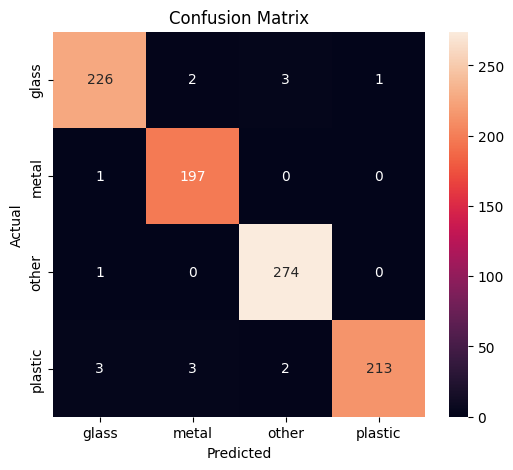

In [15]:
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=train_dataset.classes,
            yticklabels=train_dataset.classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()